In [50]:
import torch
import numpy as np
import torch.nn as nn
from sklearn import datasets
import matplotlib.pyplot as plt

In [2]:
x = torch.ones(5)
x

tensor([1., 1., 1., 1., 1.])

In [ ]:
b = x.numpy()

In [ ]:
print(type(b))

<class 'numpy.ndarray'>


In [ ]:
x+=(1)
x

tensor([3., 3., 3., 3., 3.])

## Grad Calc

In [ ]:
x = torch.randn(3, requires_grad=True)
x

tensor([ 1.1296,  1.1660, -0.0777], requires_grad=True)

In [ ]:
y = x + 2
y

tensor([3.1296, 3.1660, 1.9223], grad_fn=<AddBackward0>)

In [ ]:
z = y*y*2
z = z.mean()
z

tensor(15.6759, grad_fn=<MeanBackward0>)

In [ ]:
z.backward()


In [ ]:
x.grad

tensor([4.1729, 4.2214, 2.5631])

## Backword propagation

In [3]:
x = torch.tensor(1.0)
y = torch.tensor(2.0)
z = torch.tensor(1.0, requires_grad= True)


In [5]:
y_hat = z *x
loss = (y_hat - y)**2

In [6]:
loss

tensor(1., grad_fn=<PowBackward0>)

In [7]:
loss.backward()

In [9]:
z.grad

tensor(-2.)

## Gradient Descent

In [16]:
x = torch.tensor([1,2,3,4],dtype=torch.float32)
y = torch.tensor([2,4,6,8],dtype=torch.float32)
w = torch.tensor(0.0,dtype=torch.float32, requires_grad= True)

In [11]:
def forward(x):
  return w * x

def loss(y,y_pred):
  return ((y_pred - y)**2).mean()


In [12]:
def Gradient(x,y,y_predicted):
  return np.dot(2*x,y_predicted-y).mean()

In [13]:
print(f'before loss f(5)= {forward(5):.3f}')

before loss f(5)= 0.000


In [18]:
learning_rate = 0.01
n_iter = 100
for epoch in range(n_iter):
  y_pred = forward(x)
  l = loss(y,y_pred)
  l.backward()
  with torch.no_grad():
    w-=learning_rate*w.grad

  w.grad.zero_()
  if epoch%2 ==0:
    print(f'epoch {epoch + 1} : w : {w}, loss : {l}')

print(f'before loss f(5)= {forward(5):.3f}')

epoch 1 : w : 1.934108853340149, loss : 0.0450688973069191
epoch 3 : w : 1.952393651008606, loss : 0.02352631464600563
epoch 5 : w : 1.9656044244766235, loss : 0.012280836701393127
epoch 7 : w : 1.9751492738723755, loss : 0.0064106592908501625
epoch 9 : w : 1.982045292854309, loss : 0.0033464201260358095
epoch 11 : w : 1.987027645111084, loss : 0.0017468547448515892
epoch 13 : w : 1.9906275272369385, loss : 0.0009118800517171621
epoch 15 : w : 1.9932283163070679, loss : 0.0004760062729474157
epoch 17 : w : 1.9951075315475464, loss : 0.0002484779979567975
epoch 19 : w : 1.9964652061462402, loss : 0.00012970640091225505
epoch 21 : w : 1.9974461793899536, loss : 6.770494655938819e-05
epoch 23 : w : 1.998154878616333, loss : 3.5343608033144847e-05
epoch 25 : w : 1.9986668825149536, loss : 1.844714643084444e-05
epoch 27 : w : 1.9990367889404297, loss : 9.631531611375976e-06
epoch 29 : w : 1.9993040561676025, loss : 5.027383849665057e-06
epoch 31 : w : 1.9994971752166748, loss : 2.6243997126

## 06 Training pipeline : model - loss - optimization

In [19]:
import torch.nn as nn

In [20]:
nn.MSELoss()
optimizer = torch.optim.SGD([w],lr= learning_rate)

learning_rate = 0.01
n_iter = 100
for epoch in range(n_iter):
  y_pred = forward(x)
  l = loss(y,y_pred)
  l.backward()

  optimizer.step()
  optimizer.zero_grad()
  if epoch%2 ==0:
    print(f'epoch {epoch + 1} : w : {w}, loss : {l}')

print(f'before loss f(5)= {forward(5):.3f}')

epoch 1 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 3 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 5 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 7 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 9 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 11 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 13 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 15 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 17 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 19 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 21 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 23 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 25 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 27 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 29 : w : 1.9999996423721313, loss : 8.988365607365267e-13
epoch 31 : w : 1.9999996423721313, loss : 8.9

## linear Regression

In [41]:
# data preparation
X_numpy , Y_numpy = datasets.make_regression(n_features=1, n_samples=100, noise=20, random_state=1)
x = torch.from_numpy(X_numpy.astype(np.float32))
y = torch.from_numpy(Y_numpy.astype(np.float32))


In [42]:
y=y.view(y.shape[0],1)
y

tensor([[-5.5539e+01],
        [-1.0662e+01],
        [ 2.2757e+01],
        [ 1.0110e+02],
        [ 1.4434e+02],
        [ 3.3289e+01],
        [ 3.3015e+01],
        [-2.5887e+01],
        [-9.9639e+01],
        [ 2.3803e+01],
        [-4.5589e+01],
        [-8.3388e+00],
        [-9.5315e+01],
        [ 3.6407e+01],
        [-8.7293e+01],
        [ 6.7669e+01],
        [-1.3687e+01],
        [-5.5441e+01],
        [-6.5340e+01],
        [-5.4450e+01],
        [-2.8835e+01],
        [ 1.7884e+02],
        [ 6.5084e+01],
        [ 2.6668e+01],
        [-1.8546e+01],
        [-4.1499e+01],
        [ 8.5583e-01],
        [ 4.4562e+01],
        [ 1.1598e+02],
        [-6.4620e+01],
        [-2.5931e+01],
        [-6.0882e+01],
        [ 1.8720e+01],
        [ 7.5070e+01],
        [ 1.1720e+02],
        [-2.2698e+01],
        [-5.6363e+01],
        [ 1.8084e+02],
        [-1.9257e+02],
        [ 6.8503e+01],
        [ 1.6552e+02],
        [ 1.0500e+02],
        [-7.0434e+01],
        [-5

In [43]:
n_samples , n_features = x.shape

In [44]:
input_size = n_features
output_size = 1

In [45]:
model = nn.Linear(input_size, output_size)

In [46]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr= learning_rate)

In [47]:
n_iter = 100
for epoch in range(n_iter):
  y_predicted = model(x)
  loss = criterion(y_predicted,y)
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  if epoch%10 ==0:
    print(f'epoch {epoch + 1}, loss : {loss.item()}')

epoch 1, loss : 5671.2216796875
epoch 11, loss : 4201.73681640625
epoch 21, loss : 3139.383544921875
epoch 31, loss : 2370.496337890625
epoch 41, loss : 1813.42529296875
epoch 51, loss : 1409.4278564453125
epoch 61, loss : 1116.1793212890625
epoch 71, loss : 903.1443481445312
epoch 81, loss : 748.263671875
epoch 91, loss : 635.58349609375


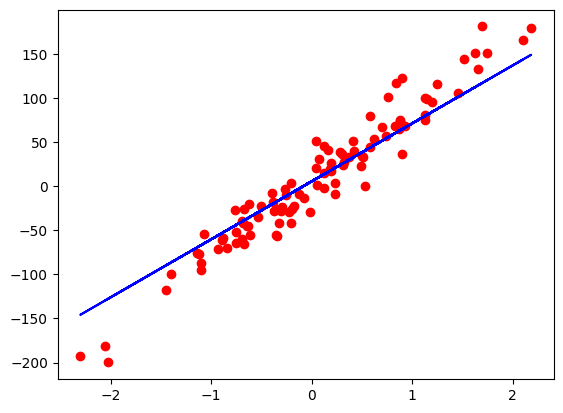

In [48]:
predicted = model(x).detach().numpy()
plt.plot(X_numpy,Y_numpy,'ro')
plt.plot(X_numpy, predicted, 'b')

plt.show()

## 08 Logistic Regression

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [52]:
bc = datasets.load_breast_cancer()
x,y = bc.data, bc.target

In [54]:
n_samples,n_features = x.shape
n_samples

569

In [55]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=1234)

In [56]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

